In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3

from scipy.stats import linregress

In [3]:
conn = sqlite3.connect("../bluestock_mf.db")

print("Database Connected")

Database Connected


In [4]:
query = """
SELECT name
FROM sqlite_master
WHERE type='table';
"""

tables = pd.read_sql(query, conn)

tables

,name
0,dim_fund
1,fact_nav
2,fact_aum
3,fact_sip_inflows
4,fact_category_inflows
5,fact_folio_count
6,fact_performance
7,fact_transactions
8,fact_portfolio_holdings
9,fact_benchmark_indices


In [5]:
query = """
PRAGMA table_info(fact_nav);
"""

pd.read_sql(query, conn)

,cid,name,type,notnull,dflt_value,pk
0,0,amfi_code,BIGINT,0,None,0
1,1,date,TEXT,0,None,0
2,2,nav,FLOAT,0,None,0


In [6]:
pd.read_sql(query, conn)

,cid,name,type,notnull,dflt_value,pk
0,0,amfi_code,BIGINT,0,None,0
1,1,date,TEXT,0,None,0
2,2,nav,FLOAT,0,None,0


In [7]:
nav_df = pd.read_sql(
    """
    SELECT *
    FROM fact_nav
    """,
    conn
)

nav_df.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [8]:
print(nav_df.shape)

(46000, 3)


In [9]:
nav_df['daily_return'].describe()

KeyError: 'daily_return'

In [10]:
print(nav_df.columns)

Index(['amfi_code', 'date', 'nav'], dtype='object')


In [11]:
nav_df['date'] = pd.to_datetime(nav_df['date'])

In [12]:
nav_df = nav_df.sort_values(
    ['amfi_code', 'date']
)

In [13]:
nav_df['daily_return'] = (
    nav_df.groupby('amfi_code')['nav']
          .pct_change()
)

In [14]:
print(nav_df.columns)

Index(['amfi_code', 'date', 'nav', 'daily_return'], dtype='object')


In [15]:
nav_df.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [16]:
nav_df['daily_return'].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

In [17]:
nav_df.to_csv(
    "../reports/daily_returns.csv",
    index=False
)

In [18]:
nav_df['amfi_code'].nunique()

40

In [19]:
print("Start Date:", nav_df['date'].min())
print("End Date:", nav_df['date'].max())

Start Date: 2022-01-03 00:00:00
End Date: 2026-05-29 00:00:00


In [20]:
nav_df['amfi_code'].nunique()

40

In [21]:
print("Start Date:", nav_df['date'].min())
print("End Date:", nav_df['date'].max())

Start Date: 2022-01-03 00:00:00
End Date: 2026-05-29 00:00:00


In [22]:
def calculate_cagr(df, years):

    end_date = df['date'].max()

    start_date = end_date - pd.DateOffset(years=years)

    temp = df[df['date'] >= start_date]

    if len(temp) < 2:
        return np.nan

    start_nav = temp.iloc[0]['nav']
    end_nav = temp.iloc[-1]['nav']

    cagr = ((end_nav / start_nav) ** (1 / years)) - 1

    return cagr

In [23]:
first_fund = nav_df['amfi_code'].unique()[0]

fund_data = nav_df[
    nav_df['amfi_code'] == first_fund
]

print("1Y CAGR:", calculate_cagr(fund_data, 1))
print("3Y CAGR:", calculate_cagr(fund_data, 3))
print("5Y CAGR:", calculate_cagr(fund_data, 5))

1Y CAGR: -0.02224270997710287
3Y CAGR: 0.01292649342495622
5Y CAGR: 0.023168434686413164


In [24]:
def calculate_cagr(df, years):

    end_date = df['date'].max()

    start_date = end_date - pd.DateOffset(years=years)

    temp = df[df['date'] >= start_date]

    # Check if enough history exists
    actual_years = (
        (temp['date'].max() - temp['date'].min()).days
    ) / 365.25

    if actual_years < years * 0.95:
        return np.nan

    start_nav = temp.iloc[0]['nav']
    end_nav = temp.iloc[-1]['nav']

    return ((end_nav / start_nav) ** (1 / years)) - 1

In [25]:
cagr_results = []

for fund in nav_df['amfi_code'].unique():

    temp = nav_df[
        nav_df['amfi_code'] == fund
    ]

    cagr_results.append({

        "amfi_code": fund,

        "cagr_1yr":
        calculate_cagr(temp, 1),

        "cagr_3yr":
        calculate_cagr(temp, 3),

        "cagr_5yr":
        calculate_cagr(temp, 5)

    })

cagr_df = pd.DataFrame(cagr_results)

In [26]:
cagr_df.head()

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr
0,100016,-0.022243,0.012926,NaN
1,100025,0.037050,0.039164,NaN
2,100033,0.532324,0.324425,NaN
3,101206,0.479241,0.289677,NaN
4,101207,-0.239860,-0.041524,NaN


In [27]:
cagr_df.sort_values(
    "cagr_3yr",
    ascending=False
).head(10)

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr
16,119094,0.222611,0.351118,NaN
34,148567,0.203607,0.340009,NaN
24,120504,0.130643,0.324874,NaN
2,100033,0.532324,0.324425,NaN
25,120505,0.296047,0.317775,NaN
19,119551,0.604373,0.304565,NaN
30,120843,0.266571,0.295828,NaN
36,148569,0.397518,0.291789,NaN
3,101206,0.479241,0.289677,NaN
39,149324,0.651387,0.270004,NaN


In [28]:
cagr_df.to_csv(
    "../reports/cagr_comparison.csv",
    index=False
)

In [29]:
rf = 0.065

In [30]:
def sharpe_ratio(returns):

    annual_return = returns.mean() * 252

    annual_volatility = (
        returns.std() * np.sqrt(252)
    )

    sharpe = (
        annual_return - rf
    ) / annual_volatility

    return sharpe

In [31]:
first_fund = nav_df['amfi_code'].unique()[0]

fund_returns = nav_df[
    nav_df['amfi_code'] == first_fund
]['daily_return'].dropna()

print(
    sharpe_ratio(fund_returns)
)

-0.20151706755966936


In [32]:
sharpe_results = []

for fund in nav_df['amfi_code'].unique():

    temp = nav_df[
        nav_df['amfi_code'] == fund
    ]

    returns = temp[
        'daily_return'
    ].dropna()

    sharpe_results.append({

        "amfi_code": fund,

        "sharpe_ratio":
        sharpe_ratio(returns)

    })

sharpe_df = pd.DataFrame(
    sharpe_results
)

In [33]:
sharpe_df = sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
)

sharpe_df.head(10)

,amfi_code,sharpe_ratio
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101
38,149323,1.132122
2,100033,1.093699
9,118632,1.081659
3,101206,1.027213
24,120504,1.026524


In [34]:
sharpe_df.to_csv(
    "../reports/sharpe_ratio_rankings.csv",
    index=False
)

In [35]:
def sortino_ratio(returns):

    downside_returns = returns[
        returns < 0
    ]

    downside_std = (
        downside_returns.std()
        * np.sqrt(252)
    )

    annual_return = (
        returns.mean()
        * 252
    )

    sortino = (
        annual_return - rf
    ) / downside_std

    return sortino

In [36]:
first_fund = nav_df['amfi_code'].unique()[0]

returns = nav_df[
    nav_df['amfi_code'] == first_fund
]['daily_return'].dropna()

print(
    sortino_ratio(returns)
)

-0.3510474601523089


In [37]:
sortino_results = []

for fund in nav_df['amfi_code'].unique():

    temp = nav_df[
        nav_df['amfi_code'] == fund
    ]

    returns = temp[
        'daily_return'
    ].dropna()

    sortino_results.append({

        "amfi_code": fund,

        "sortino_ratio":
        sortino_ratio(returns)

    })

sortino_df = pd.DataFrame(
    sortino_results
)

In [38]:
sortino_df = sortino_df.sort_values(
    "sortino_ratio",
    ascending=False
)

sortino_df.head(10)

,amfi_code,sortino_ratio
34,148567,2.385644
30,120843,2.364320
36,148569,2.146914
19,119551,2.140267
25,120505,2.029353
38,149323,1.875101
9,118632,1.850133
2,100033,1.829134
24,120504,1.805294
3,101206,1.799563


In [39]:
sortino_df.to_csv(
    "../reports/sortino_ratio_rankings.csv",
    index=False
)

In [40]:
sortino_df.head(10)

,amfi_code,sortino_ratio
34,148567,2.385644
30,120843,2.364320
36,148569,2.146914
19,119551,2.140267
25,120505,2.029353
38,149323,1.875101
9,118632,1.850133
2,100033,1.829134
24,120504,1.805294
3,101206,1.799563


In [41]:
query = """
PRAGMA table_info(fact_benchmark_indices);
"""

pd.read_sql(query, conn)

,cid,name,type,notnull,dflt_value,pk
0,0,date,TEXT,0,None,0
1,1,index_name,TEXT,0,None,0
2,2,close_value,FLOAT,0,None,0


In [42]:
benchmark_df = pd.read_sql(
    """
    SELECT *
    FROM fact_benchmark_indices
    """,
    conn
)

benchmark_df['index_name'].unique()

array(['NIFTY50', 'NIFTY100', 'NIFTY_MIDCAP150', 'BSE_SMALLCAP',
       'NIFTY500', 'CRISIL_LIQUID', 'CRISIL_GILT'], dtype=object)

In [43]:
benchmark_df['index_name'].unique()

array(['NIFTY50', 'NIFTY100', 'NIFTY_MIDCAP150', 'BSE_SMALLCAP',
       'NIFTY500', 'CRISIL_LIQUID', 'CRISIL_GILT'], dtype=object)

In [44]:
nifty100 = benchmark_df[
    benchmark_df['index_name'] == 'NIFTY100'
].copy()

In [45]:
nifty100['date'] = pd.to_datetime(
    nifty100['date']
)

In [46]:
nifty100 = nifty100.sort_values(
    'date'
)

In [47]:
nifty100['benchmark_return'] = (
    nifty100['close_value']
    .pct_change()
)

In [48]:
nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [49]:
alpha_beta_results = []

In [50]:
for fund in nav_df['amfi_code'].unique():

    fund_data = nav_df[
        nav_df['amfi_code'] == fund
    ][['date', 'daily_return']]

    merged = pd.merge(
        fund_data,
        nifty100[['date', 'benchmark_return']],
        on='date',
        how='inner'
    )

    merged = merged.dropna()

    if len(merged) < 30:
        continue

    result = linregress(
        merged['benchmark_return'],
        merged['daily_return']
    )

    alpha = result.intercept * 252
    beta = result.slope

    alpha_beta_results.append({
        'amfi_code': fund,
        'alpha': alpha,
        'beta': beta
    })

In [51]:
alpha_beta_df = pd.DataFrame(
    alpha_beta_results
)

In [52]:
alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [53]:
print(len(merged))
print(merged.head())

1149
        date  daily_return  benchmark_return
1 2022-01-04     -0.010498         -0.013540
2 2022-01-05     -0.002593          0.004003
3 2022-01-06     -0.008382         -0.002935
4 2022-01-07      0.011680          0.006150
5 2022-01-10      0.001356         -0.008351


In [54]:
fund = nav_df['amfi_code'].unique()[0]

fund_data = nav_df[
    nav_df['amfi_code'] == fund
][['date', 'daily_return']]

merged = pd.merge(
    fund_data,
    nifty100[['date', 'benchmark_return']],
    on='date',
    how='inner'
)

merged = merged.dropna()

merged.head()

,date,daily_return,benchmark_return
1,2022-01-04,-0.010306,-0.013540
2,2022-01-05,0.012865,0.004003
3,2022-01-06,-0.011377,-0.002935
4,2022-01-07,-0.001210,0.006150
5,2022-01-10,-0.008639,-0.008351


In [55]:
alpha_beta_df.sort_values(
    'beta',
    ascending=False
).head(10)

,amfi_code,alpha,beta
11,118634,0.175007,0.103497
22,119599,0.048824,0.062002
32,125497,0.177298,0.048820
26,120506,0.162539,0.041896
28,120841,0.130429,0.036356
15,119093,0.082328,0.025883
34,148567,0.269838,0.023684
3,101206,0.213998,0.021086
36,148569,0.282704,0.018134
29,120842,0.078044,0.018057


In [56]:
alpha_beta_df['beta'].describe()

count    40.000000
mean     -0.001958
std       0.035194
min      -0.066951
25%      -0.023937
50%      -0.000067
75%       0.017026
max       0.103497
Name: beta, dtype: float64

In [57]:
alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)


In [58]:
def max_drawdown(nav_series):
    running_max = nav_series.cummax()

    drawdown = (
        nav_series / running_max
    ) - 1

    return drawdown.min()

In [59]:
print(
    max_drawdown(
        first_fund['nav']
    )
)

IndexError: invalid index to scalar variable.

In [60]:
print(type(first_fund))
print(first_fund)

<class 'numpy.int64'>
100016


In [61]:
first_fund_df = nav_df[
    nav_df['amfi_code']
    ==
    nav_df['amfi_code'].unique()[0]
]

In [62]:
first_fund_df.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [63]:
print(
    max_drawdown(
        first_fund_df['nav']
    )
)

-0.24734440880673303


In [64]:
drawdown_results = []

for fund in nav_df['amfi_code'].unique():

    temp = nav_df[
        nav_df['amfi_code'] == fund
    ]

    dd = max_drawdown(
        temp['nav']
    )

    drawdown_results.append({
        'amfi_code': fund,
        'max_drawdown': dd
    })

drawdown_df = pd.DataFrame(
    drawdown_results
)

In [65]:
drawdown_df.sort_values(
    'max_drawdown'
).head(10)

,amfi_code,max_drawdown
22,119599,-0.525742
17,119095,-0.516778
4,101207,-0.354469
39,149324,-0.311719
21,119598,-0.287060
7,102886,-0.280011
0,100016,-0.247344
29,120842,-0.240035
11,118634,-0.233449
15,119093,-0.217514


In [66]:
drawdown_df.to_csv(
    "../reports/max_drawdown.csv",
    index=False
)

In [67]:
pd.read_sql(
    """
    PRAGMA table_info(dim_fund);
    """,
    conn
)

,cid,name,type,notnull,dflt_value,pk
0,0,amfi_code,BIGINT,0,None,0
1,1,fund_house,TEXT,0,None,0
2,2,scheme_name,TEXT,0,None,0
3,3,category,TEXT,0,None,0
4,4,sub_category,TEXT,0,None,0
5,5,plan,TEXT,0,None,0
6,6,launch_date,TEXT,0,None,0
7,7,benchmark,TEXT,0,None,0
8,8,expense_ratio_pct,FLOAT,0,None,0
9,9,exit_load_pct,FLOAT,0,None,0


In [68]:
expense_df = pd.read_sql(
    """
    SELECT
        amfi_code,
        expense_ratio_pct
    FROM dim_fund
    """,
    conn
)

expense_df.head()

,amfi_code,expense_ratio_pct
0,119551,1.54
1,119552,0.66
2,119598,1.43
3,119599,0.72
4,119120,0.77


In [69]:
scorecard = cagr_df.merge(
    sharpe_df,
    on='amfi_code'
)

scorecard = scorecard.merge(
    alpha_beta_df[['amfi_code','alpha']],
    on='amfi_code'
)

scorecard = scorecard.merge(
    drawdown_df,
    on='amfi_code'
)

scorecard = scorecard.merge(
    expense_df,
    on='amfi_code'
)

In [70]:
scorecard.head()

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr,sharpe_ratio,alpha,max_drawdown,expense_ratio_pct
0,100016,-0.022243,0.012926,NaN,-0.201517,0.037476,-0.247344,1.55
1,100025,0.037050,0.039164,NaN,-0.567095,0.042818,-0.043083,0.56
2,100033,0.532324,0.324425,NaN,1.093699,0.271954,-0.162172,1.38
3,101206,0.479241,0.289677,NaN,1.027213,0.213998,-0.112916,1.60
4,101207,-0.239860,-0.041524,NaN,0.162661,0.108971,-0.354469,1.53


In [71]:
scorecard['rank_3yr'] = scorecard[
    'cagr_3yr'
].rank(
    ascending=False
)

scorecard['rank_sharpe'] = scorecard[
    'sharpe_ratio'
].rank(
    ascending=False
)

scorecard['rank_alpha'] = scorecard[
    'alpha'
].rank(
    ascending=False
)

scorecard['rank_expense'] = scorecard[
    'expense_ratio_pct'
].rank(
    ascending=True
)

scorecard['rank_dd'] = scorecard[
    'max_drawdown'
].rank(
    ascending=False
)

In [72]:
scorecard['raw_score'] = (

    0.30 * scorecard['rank_3yr']

    +

    0.25 * scorecard['rank_sharpe']

    +

    0.20 * scorecard['rank_alpha']

    +

    0.15 * scorecard['rank_expense']

    +

    0.10 * scorecard['rank_dd']

)

In [73]:
scorecard['fund_score'] = (

    scorecard['raw_score']

    /

    scorecard['raw_score'].max()

) * 100

In [74]:
scorecard = scorecard.sort_values(
    'fund_score',
    ascending=False
)

scorecard.head(10)

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr,sharpe_ratio,alpha,max_drawdown,expense_ratio_pct,rank_3yr,rank_sharpe,rank_alpha,rank_expense,rank_dd,raw_score,fund_score
7,102886,-0.167975,-0.007674,NaN,-0.205832,0.028969,-0.280011,1.51,37.0,36.0,40.0,24.5,35.0,35.275,100.000000
0,100016,-0.022243,0.012926,NaN,-0.201517,0.037476,-0.247344,1.55,35.0,35.0,39.0,32.0,34.0,35.250,99.929128
17,119095,-0.427976,-0.117058,NaN,-0.075974,0.048016,-0.516778,1.38,40.0,33.0,37.0,17.0,39.0,34.100,96.669029
4,101207,-0.239860,-0.041524,NaN,0.162661,0.108971,-0.354469,1.53,39.0,28.0,27.0,28.5,38.0,32.175,91.211906
14,119092,0.016091,0.005259,NaN,0.030785,0.068995,-0.144016,1.64,36.0,31.0,30.0,39.5,15.0,31.975,90.644933
22,119599,0.139478,-0.013374,NaN,-0.057187,0.048824,-0.525742,0.72,38.0,32.0,36.0,5.5,40.0,31.425,89.085755
29,120842,0.225020,0.077560,NaN,0.076000,0.078044,-0.240035,1.56,28.0,30.0,29.0,33.0,33.0,29.950,84.904323
1,100025,0.037050,0.039164,NaN,-0.567095,0.042818,-0.043083,0.56,34.0,39.0,38.0,2.0,4.0,28.250,80.085046
5,101208,0.072366,0.063158,NaN,-0.815567,0.060861,-0.001622,0.79,31.0,40.0,33.0,11.0,3.0,27.850,78.951099
18,119120,0.055220,0.058404,NaN,-0.226575,0.056209,-0.043287,0.77,32.0,37.0,34.0,9.0,5.0,27.500,77.958894


In [75]:
n = len(scorecard)

scorecard['score_3yr'] = n + 1 - scorecard['rank_3yr']
scorecard['score_sharpe'] = n + 1 - scorecard['rank_sharpe']
scorecard['score_alpha'] = n + 1 - scorecard['rank_alpha']
scorecard['score_expense'] = n + 1 - scorecard['rank_expense']
scorecard['score_dd'] = n + 1 - scorecard['rank_dd']

In [76]:
scorecard['raw_score'] = (
    0.30 * scorecard['score_3yr']
    + 0.25 * scorecard['score_sharpe']
    + 0.20 * scorecard['score_alpha']
    + 0.15 * scorecard['score_expense']
    + 0.10 * scorecard['score_dd']
)

In [77]:
scorecard['fund_score'] = (
    scorecard['raw_score']
    / scorecard['raw_score'].max()
) * 100

In [78]:
scorecard = scorecard.sort_values(
    'fund_score',
    ascending=False
)

In [79]:
scorecard.head(10)

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr,sharpe_ratio,alpha,max_drawdown,expense_ratio_pct,rank_3yr,rank_sharpe,rank_alpha,rank_expense,rank_dd,raw_score,fund_score,score_3yr,score_sharpe,score_alpha,score_expense,score_dd
34,148567,0.203607,0.340009,NaN,1.448291,0.269838,-0.112657,1.46,2.0,1.0,7.0,23.0,8.0,34.500,100.000000,39.0,40.0,34.0,18.0,33.0
25,120505,0.296047,0.317775,NaN,1.180101,0.292636,-0.181885,1.36,5.0,5.0,3.0,15.0,25.0,32.900,95.362319,36.0,36.0,38.0,26.0,16.0
30,120843,0.266571,0.295828,NaN,1.306744,0.273305,-0.129740,1.45,7.0,2.0,5.0,22.0,13.0,32.800,95.072464,34.0,39.0,36.0,19.0,28.0
2,100033,0.532324,0.324425,NaN,1.093699,0.271954,-0.162172,1.38,4.0,7.0,6.0,17.0,20.0,32.300,93.623188,37.0,34.0,35.0,24.0,21.0
24,120504,0.130643,0.324874,NaN,1.026524,0.211948,-0.125883,0.80,3.0,10.0,13.0,12.0,12.0,32.000,92.753623,38.0,31.0,28.0,29.0,29.0
16,119094,0.222611,0.351118,NaN,0.998231,0.260767,-0.209609,1.38,1.0,11.0,9.0,17.0,28.0,30.800,89.275362,40.0,30.0,32.0,24.0,13.0
19,119551,0.604373,0.304565,NaN,1.208267,0.232010,-0.150124,1.54,6.0,4.0,10.0,30.5,17.0,29.925,86.739130,35.0,37.0,31.0,10.5,24.0
36,148569,0.397518,0.291789,NaN,1.234930,0.282704,-0.163967,1.60,8.0,3.0,4.0,36.5,21.0,29.475,85.434783,33.0,38.0,37.0,4.5,20.0
3,101206,0.479241,0.289677,NaN,1.027213,0.213998,-0.112916,1.60,9.0,9.0,12.0,36.5,9.0,27.275,79.057971,32.0,32.0,29.0,4.5,32.0
21,119598,0.827761,0.266699,NaN,0.945308,0.303370,-0.287060,1.43,12.0,14.0,1.0,21.0,36.0,26.950,78.115942,29.0,27.0,40.0,20.0,5.0


In [80]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

In [81]:
top5_funds = scorecard.head(5)

top5_funds[['amfi_code', 'fund_score']]

,amfi_code,fund_score
34,148567,100.000000
25,120505,95.362319
30,120843,95.072464
2,100033,93.623188
24,120504,92.753623


In [82]:
fund_names = pd.read_sql(
    """
    SELECT
        amfi_code,
        scheme_name
    FROM dim_fund
    """,
    conn
)

In [83]:
top5_funds = top5_funds.merge(
    fund_names,
    on='amfi_code'
)

In [84]:
nifty50 = benchmark_df[
    benchmark_df['index_name'] == 'NIFTY50'
].copy()

nifty50['date'] = pd.to_datetime(
    nifty50['date']
)

nifty50 = nifty50.sort_values(
    'date'
)

In [85]:
end_date = nav_df['date'].max()

start_date = end_date - pd.DateOffset(
    years=3
)

In [86]:
nifty50_3y = nifty50[
    nifty50['date'] >= start_date
].copy()

nifty100_3y = nifty100[
    nifty100['date'] >= start_date
].copy()

In [87]:
nifty50_3y['growth'] = (
    nifty50_3y['close_value']
    /
    nifty50_3y['close_value'].iloc[0]
) * 100

In [88]:
nifty100_3y['growth'] = (
    nifty100_3y['close_value']
    /
    nifty100_3y['close_value'].iloc[0]
) * 100

In [89]:
plt.figure(figsize=(14,8))

<Figure size 1400x800 with 0 Axes>

<Figure size 1400x800 with 0 Axes>

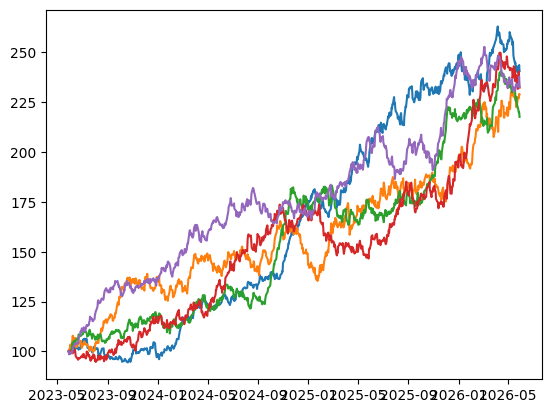

In [90]:
for fund in top5_funds['amfi_code']:

    temp = nav_df[
        (nav_df['amfi_code'] == fund)
        &
        (nav_df['date'] >= start_date)
    ].copy()

    temp['growth'] = (
        temp['nav']
        /
        temp['nav'].iloc[0]
    ) * 100

    plt.plot(
        temp['date'],
        temp['growth'],
        label=str(fund)
    )

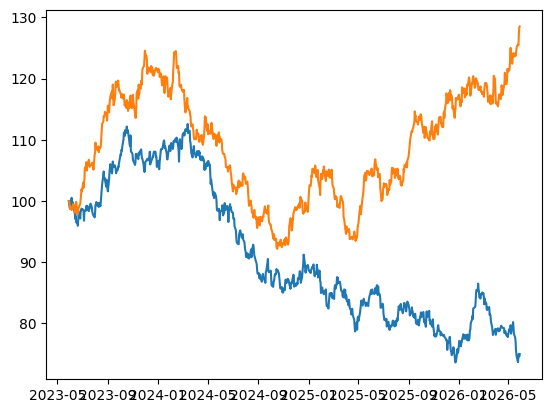

In [91]:
plt.plot(
    nifty50_3y['date'],
    nifty50_3y['growth'],
    label='NIFTY50'
)

plt.plot(
    nifty100_3y['date'],
    nifty100_3y['growth'],
    label='NIFTY100'
)

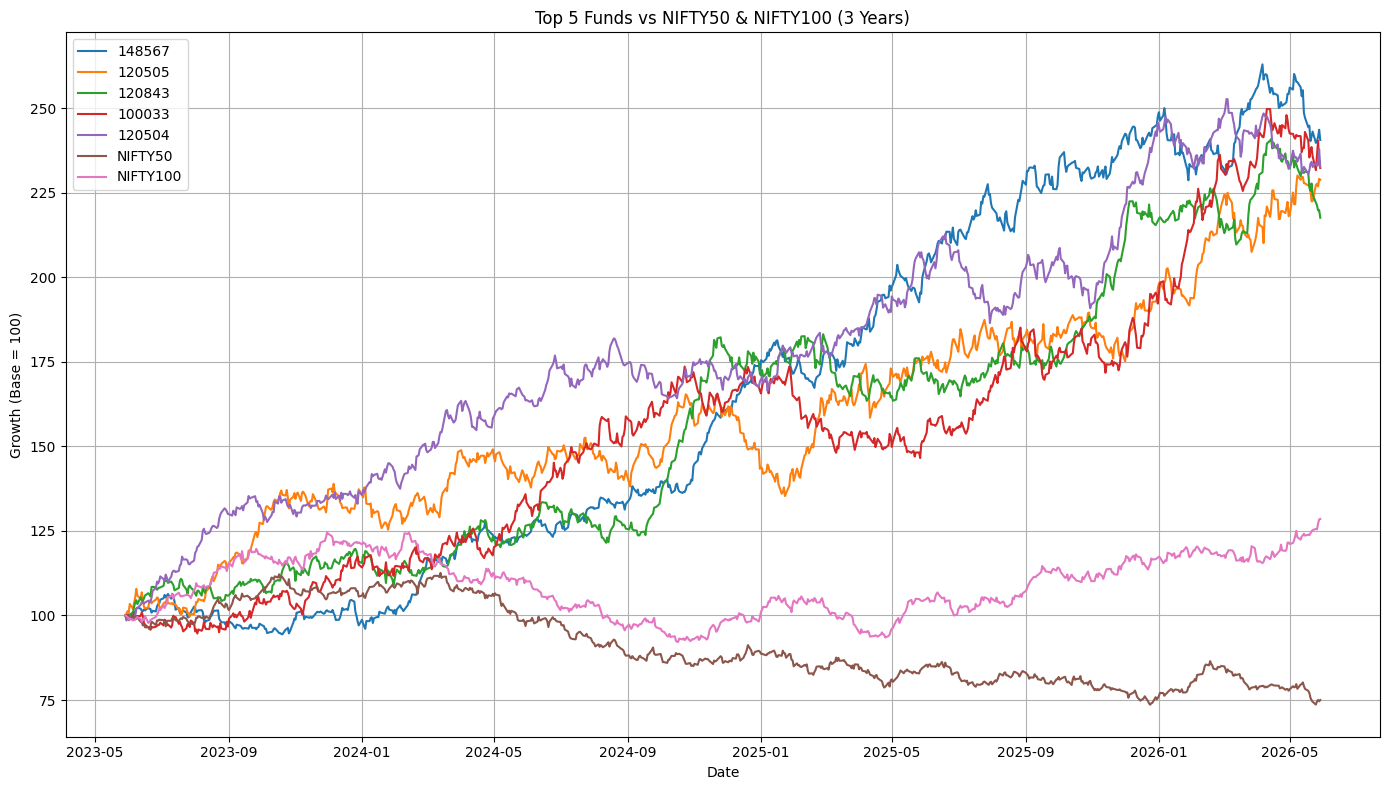

In [93]:
plt.figure(figsize=(14,8))

# Plot Top 5 Funds
for fund in top5_funds['amfi_code']:

    temp = nav_df[
        (nav_df['amfi_code'] == fund)
        &
        (nav_df['date'] >= start_date)
    ].copy()

    temp['growth'] = (
        temp['nav']
        /
        temp['nav'].iloc[0]
    ) * 100

    plt.plot(
        temp['date'],
        temp['growth'],
        label=str(fund)
    )

# Plot Benchmarks
plt.plot(
    nifty50_3y['date'],
    nifty50_3y['growth'],
    label='NIFTY50'
)

plt.plot(
    nifty100_3y['date'],
    nifty100_3y['growth'],
    label='NIFTY100'
)

# STEP 66
plt.title(
    'Top 5 Funds vs NIFTY50 & NIFTY100 (3 Years)'
)

plt.xlabel('Date')

plt.ylabel(
    'Growth (Base = 100)'
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

In [94]:
plt.savefig(
    "../reports/benchmark_comparison.png",
    bbox_inches='tight'
)

<Figure size 640x480 with 0 Axes>

In [95]:
def tracking_error(fund_returns, benchmark_returns):

    diff = fund_returns - benchmark_returns

    return diff.std() * np.sqrt(252)

In [96]:
tracking_results = []

for fund in top5_funds['amfi_code']:

    fund_data = nav_df[
        nav_df['amfi_code'] == fund
    ][['date', 'daily_return']]

    merged = pd.merge(
        fund_data,
        nifty100[['date', 'benchmark_return']],
        on='date',
        how='inner'
    )

    merged = merged.dropna()

    te = tracking_error(
        merged['daily_return'],
        merged['benchmark_return']
    )

    tracking_results.append({
        'amfi_code': fund,
        'tracking_error': te
    })

tracking_df = pd.DataFrame(tracking_results)

In [97]:
tracking_df

,amfi_code,tracking_error
0,148567,0.189664
1,120505,0.231968
2,120843,0.206425
3,100033,0.228699
4,120504,0.191587


In [98]:
tracking_df.to_csv(
    "../reports/tracking_error.csv",
    index=False
)

In [99]:
import os

os.listdir("../reports")

['alpha_beta.csv',
 'benchmark_comparison.png',
 'cagr_comparison.csv',
 'daily_returns.csv',
 'data_dictionary.md',
 'day1_anomalies.txt',
 'fund_scorecard.csv',
 'max_drawdown.csv',
 'sharpe_ratio_rankings.csv',
 'sortino_ratio_rankings.csv',
 'tracking_error.csv']